In [1]:
import pandas as pd

# Read the CSV file into a DataFrame -- this is now a table living in memory
df = pd.read_csv('cookie_cats.csv')

# Show the first 5 rows, so you can eyeball what the data looks like
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
df.shape

(90189, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [5]:
!pip install psycopg2-binary sqlalchemy

In [6]:
from sqlalchemy import create_engine

# Replace this with YOUR actual connection string from Neon
connection_string = <your connection string from Neon>
engine = create_engine(connection_string)

In [7]:
df.to_sql('cookie_cats', engine, if_exists='replace', index=False)

189

In [8]:
result = pd.read_sql("SELECT * FROM cookie_cats LIMIT 5;", engine)
result

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [9]:
# --- Clean: dedupe + outlier check ---
df_clean = df.drop_duplicates(subset='userid')
print(f"Removed {len(df) - len(df_clean)} duplicate rows")

Q1, Q3 = df_clean['sum_gamerounds'].quantile([0.25, 0.75])
upper_bound = Q3 + 3 * (Q3 - Q1)
outliers = df_clean[df_clean['sum_gamerounds'] > upper_bound]
print(f"Removing {len(outliers)} outlier(s) above {upper_bound:.0f} rounds")
df_clean = df_clean[df_clean['sum_gamerounds'] <= upper_bound]

Removed 0 duplicate rows
Removing 5704 outlier(s) above 189 rounds


In [10]:
# --- SRM check: is the 50/50 split actually clean? ---
from scipy import stats
import numpy as np

counts = df_clean['version'].value_counts()
print(counts)
expected = counts.sum() / 2
chi2 = ((counts - expected)**2 / expected).sum()
p_srm = 1 - stats.chi2.cdf(chi2, df=1)
print(f"SRM chi-square={chi2:.3f}, p={p_srm:.4f}  (p<0.001 = SRM problem)")

version
gate_40    42631
gate_30    41854
Name: count, dtype: int64
SRM chi-square=7.146, p=0.0075  (p<0.001 = SRM problem)


In [11]:
# --- Core metrics by variant ---
summary = df_clean.groupby('version').agg(
    n_users=('userid', 'count'),
    retention_1_rate=('retention_1', 'mean'),
    retention_7_rate=('retention_7', 'mean'),
    avg_rounds=('sum_gamerounds', 'mean'),
    median_rounds=('sum_gamerounds', 'median'),
)
summary

,n_users,retention_1_rate,retention_7_rate,avg_rounds,median_rounds
version,,,,,
gate_30,41854,0.415062,0.146079,30.673938,15.0
gate_40,42631,0.409538,0.137857,30.712087,14.0


In [12]:
# --- Primary metric test: 1-day retention ---
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

g30 = df_clean[df_clean['version'] == 'gate_30']
g40 = df_clean[df_clean['version'] == 'gate_40']

count1 = [g30['retention_1'].sum(), g40['retention_1'].sum()]
nobs = [len(g30), len(g40)]
z1, p1 = proportions_ztest(count1, nobs)
ci30_1 = proportion_confint(count1[0], nobs[0], method='wilson')
ci40_1 = proportion_confint(count1[1], nobs[1], method='wilson')
print(f"gate_30 ret_1: {count1[0]/nobs[0]:.4f}  CI {ci30_1}")
print(f"gate_40 ret_1: {count1[1]/nobs[1]:.4f}  CI {ci40_1}")
print(f"z={z1:.3f}, p={p1:.5f}")

gate_30 ret_1: 0.4151  CI (0.41034935455144794, 0.41978999921826954)
gate_40 ret_1: 0.4095  CI (0.4048780411446402, 0.414213581197859)
z=1.631, p=0.10291


In [13]:
# --- Secondary metric test: 7-day retention ---
count7 = [g30['retention_7'].sum(), g40['retention_7'].sum()]
z7, p7 = proportions_ztest(count7, nobs)
ci30_7 = proportion_confint(count7[0], nobs[0], method='wilson')
ci40_7 = proportion_confint(count7[1], nobs[1], method='wilson')
print(f"gate_30 ret_7: {count7[0]/nobs[0]:.4f}  CI {ci30_7}")
print(f"gate_40 ret_7: {count7[1]/nobs[1]:.4f}  CI {ci40_7}")
print(f"z={z7:.3f}, p={p7:.5f}")

gate_30 ret_7: 0.1461  CI (0.14272807972714566, 0.14949533726042766)
gate_40 ret_7: 0.1379  CI (0.13461746434637617, 0.14116265014465879)
z=3.424, p=0.00062


In [14]:
# --- Engagement (guardrail-style) metric: rounds played, non-normal so use Mann-Whitney ---
print(f"Skew: gate_30={stats.skew(g30['sum_gamerounds']):.2f}, gate_40={stats.skew(g40['sum_gamerounds']):.2f}")
u_stat, p_u = stats.mannwhitneyu(g30['sum_gamerounds'], g40['sum_gamerounds'], alternative='two-sided')
print(f"Mann-Whitney U={u_stat:.0f}, p={p_u:.5f}")

Skew: gate_30=1.92, gate_40=1.87
Mann-Whitney U=898917508, p=0.05569


In [15]:
# --- Retrospective power: smallest lift we could reliably detect at this N ---
from statsmodels.stats.power import NormalIndPower
n_per_group = min(nobs)
p_base = count1[0] / nobs[0]
h = NormalIndPower().solve_power(effect_size=None, nobs1=n_per_group, alpha=0.05, power=0.8, ratio=1)
mde = (np.sin((h + 2*np.arcsin(np.sqrt(p_base)))/2))**2 - p_base
print(f"At n={n_per_group}/group, min detectable lift (80% power) ≈ {abs(mde):.4f}")

At n=41854/group, min detectable lift (80% power) ≈ 0.0096


In [16]:
# --- Save results for Tableau + push clean table back to Postgres ---
summary.to_csv('variant_summary.csv')
df_clean.to_sql('cookie_cats_clean', engine, if_exists='replace', index=False)
df_clean.to_csv('cookie_cats_clean_full.csv', index=False)
print("Saved variant_summary.csv and cookie_cats_clean_full.csv, pushed cookie_cats_clean to Postgres")

Saved variant_summary.csv and cookie_cats_clean_full.csv, pushed cookie_cats_clean to Postgres


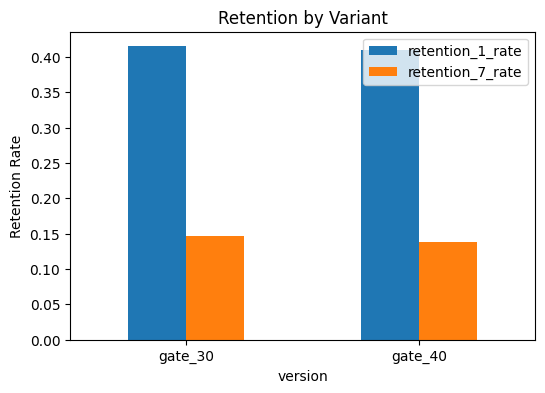

In [17]:
import matplotlib.pyplot as plt

# Retention comparison bar chart
summary[['retention_1_rate', 'retention_7_rate']].plot(kind='bar', figsize=(6,4))
plt.title('Retention by Variant')
plt.ylabel('Retention Rate')
plt.xticks(rotation=0)
plt.show()

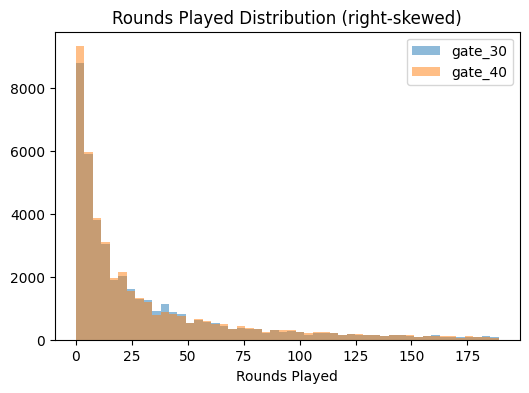

In [18]:
# Rounds played distribution -- shows the skew visually, backs up your Mann-Whitney choice
plt.figure(figsize=(6,4))
plt.hist(g30['sum_gamerounds'], bins=50, alpha=0.5, label='gate_30')
plt.hist(g40['sum_gamerounds'], bins=50, alpha=0.5, label='gate_40')
plt.legend()
plt.title('Rounds Played Distribution (right-skewed)')
plt.xlabel('Rounds Played')
plt.show()